<a href="https://colab.research.google.com/github/Tresorshingiro/Malaria-Diagnosis-CNN-Transfer-Learning/blob/main/model3_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 3: VGG16 Pre-trained Transfer Learning

**Group 10: Centralized Malaria Diagnosis Pipeline via Transfer Learning**

This notebook implements the third model in the group's malaria diagnosis pipeline using Transfer Learning via the VGG16 architecture.

VGG16 is a 16-layer deep network pre-trained on the massive ImageNet dataset. By freezing the feature extraction base and replacing the classification head, we leverage pre-existing visual pattern-recognition capabilities to identify malaria parasites in microscopic blood smears.

Seven individual experiments are systematically conducted by altering:
- Optimizers (Adam vs. SGD)
- Learning rates
- Fully Connected Dense layer sizes
- Regularization parameters (Dropout rates)
- Layer unfreezing configurations (Fine-Tuning)

## 1. Environment Setup

Enable **GPU** in Colab: *Runtime → Change runtime type → GPU*

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU device active:", tf.test.gpu_device_name())

TensorFlow version: 2.20.0
GPU device active: /device:GPU:0


## 2. Import Libraries

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading

The NIH malaria cell images dataset contains 27,560 images split equally between **Parasitized** and **Uninfected** classes.

In [3]:
if not os.path.exists('cell_images'):
    print("Downloading dataset...")
    !wget -q https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip -q cell_images.zip
    print("Done.")
else:
    print("Dataset already exists, skipping download.")

parasitized = len(os.listdir('cell_images/Parasitized'))
uninfected = len(os.listdir('cell_images/Uninfected'))
print(f"Parasitized images: {parasitized}")
print(f"Uninfected images:  {uninfected}")

Done.
Parasitized images: 13780
Uninfected images:  13780


In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Classes: ['Parasitized', 'Uninfected']


## 4. Evaluation Helper Functions

In [5]:
def evaluate_model(model, dataset):
    """Run inference on a dataset and return true labels, predicted labels, and raw scores."""
    y_true, y_pred, y_scores = [], [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend((preds > 0.5).astype(int).flatten())
        y_scores.extend(preds.flatten())
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    return np.array(y_true), np.array(y_pred), np.array(y_scores)


def plot_learning_curves(history, title="Learning Curves"):
    """Plot training vs validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Plot a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='black')
    plt.xticks([0, 1], CLASS_NAMES)
    plt.yticks([0, 1], CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_scores, title="ROC Curve"):
    """Plot ROC curve and print AUC score."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"AUC: {roc_auc:.4f}")
    return roc_auc


print("Helper functions defined successfully.")

Helper functions defined successfully.


## 5. Core Reusable Model Builder Function

In [6]:
def build_vgg16_model(dense_units=256, dropout_rate=0.5, learning_rate=1e-3, optimizer_name="adam", fine_tune_layers=0):
    """
    Builds a VGG16 Transfer Learning model for Malaria classification.
    Adapts the network input dimensions to match the group dataset standard of 128x128x3.
    """
    base_vgg = tf.keras.applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(128, 128, 3)
    )

    if fine_tune_layers == 0:
        base_vgg.trainable = False
    else:
        base_vgg.trainable = True
        for layer in base_vgg.layers[:-fine_tune_layers]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=(128, 128, 3))
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = base_vgg(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    if optimizer_name == "adam":
        opt = Adam(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

## 6. Running The 7 Mandatory Individual Experiments

In [7]:
print("[Executing] Experiment 1 — The Transfer Learning Baseline")
vgg_e1 = build_vgg16_model(dense_units=256, dropout_rate=0.5, learning_rate=1e-3, optimizer_name="adam")
hist_vgg1 = vgg_e1.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

[Executing] Experiment 1 — The Transfer Learning Baseline
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 91s 91ms/step - accuracy: 0.8805 - loss: 0.2930 - val_accuracy: 0.9238 - val_loss: 0.1973
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.9200 - loss: 0.2104 - val_accuracy: 0.9329 - val_loss: 0.1793
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9265 - loss: 0.1954 - val_accuracy: 0.9350 - val_loss: 0.1715
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9287 - loss: 0.1888 - val_accuracy: 0.9320 - val_loss: 0.1736
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9313 - loss: 0.1833 - val_accuracy: 0.9332 - val_loss: 0.1672
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9317 - loss: 0.1803 - val_accuracy: 0.9320 - val_loss: 0.1717
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9325 - loss: 0.1769 - val_accuracy: 0.9334 

In [8]:
print("[Executing] Experiment 2 — Lowering the Learning Rate")
vgg_e2 = build_vgg16_model(dense_units=256, dropout_rate=0.5, learning_rate=1e-4, optimizer_name="adam")
hist_vgg2 = vgg_e2.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

[Executing] Experiment 2 — Lowering the Learning Rate
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 67s 93ms/step - accuracy: 0.7764 - loss: 0.4821 - val_accuracy: 0.8788 - val_loss: 0.3432
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.8882 - loss: 0.3065 - val_accuracy: 0.9069 - val_loss: 0.2628
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9059 - loss: 0.2540 - val_accuracy: 0.9163 - val_loss: 0.2311
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9148 - loss: 0.2285 - val_accuracy: 0.9185 - val_loss: 0.2117
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9197 - loss: 0.2132 - val_accuracy: 0.9229 - val_loss: 0.2011
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 69s 101ms/step - accuracy: 0.9236 - loss: 0.2041 - val_accuracy: 0.9272 - val_loss: 0.1934
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9247 - loss: 0.1967 - val_accuracy: 0.9309 - val_loss: 0.1866
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━

In [9]:
print("[Executing] Experiment 3 — Changing the Optimizer to SGD")
vgg_e3 = build_vgg16_model(dense_units=256, dropout_rate=0.5, learning_rate=1e-3, optimizer_name="sgd")
hist_vgg3 = vgg_e3.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

[Executing] Experiment 3 — Changing the Optimizer to SGD
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 92ms/step - accuracy: 0.7147 - loss: 0.5685 - val_accuracy: 0.8120 - val_loss: 0.4523
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.8343 - loss: 0.4110 - val_accuracy: 0.8733 - val_loss: 0.3420
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.8710 - loss: 0.3372 - val_accuracy: 0.8886 - val_loss: 0.2926
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.8862 - loss: 0.2967 - val_accuracy: 0.9044 - val_loss: 0.2583
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.8955 - loss: 0.2722 - val_accuracy: 0.9105 - val_loss: 0.2414
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9006 - loss: 0.2593 - val_accuracy: 0.9158 - val_loss: 0.2288
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9072 - loss: 0.2449 - val_accuracy: 0.9134 - val_loss: 0.2215
Epoch 8/10
689/689 ━━━━━━━━━━━━━━

In [10]:
print("[Executing] Experiment 4 — Reducing Dense Neurons")
vgg_e4 = build_vgg16_model(dense_units=64, dropout_rate=0.5, learning_rate=1e-3, optimizer_name="adam")
hist_vgg4 = vgg_e4.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

[Executing] Experiment 4 — Reducing Dense Neurons
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 67s 93ms/step - accuracy: 0.8557 - loss: 0.3511 - val_accuracy: 0.9107 - val_loss: 0.2253
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9166 - loss: 0.2269 - val_accuracy: 0.9214 - val_loss: 0.2063
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9251 - loss: 0.2054 - val_accuracy: 0.9314 - val_loss: 0.1785
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9289 - loss: 0.1961 - val_accuracy: 0.9334 - val_loss: 0.1716
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9303 - loss: 0.1922 - val_accuracy: 0.9323 - val_loss: 0.1707
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9311 - loss: 0.1872 - val_accuracy: 0.9340 - val_loss: 0.1709
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9326 - loss: 0.1842 - val_accuracy: 0.9359 - val_loss: 0.1651
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
print("[Executing] Experiment 5 — Increasing Dropout Regularization")
vgg_e5 = build_vgg16_model(dense_units=256, dropout_rate=0.7, learning_rate=1e-3, optimizer_name="adam")
hist_vgg5 = vgg_e5.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

[Executing] Experiment 5 — Increasing Dropout Regularization
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 94ms/step - accuracy: 0.8595 - loss: 0.3327 - val_accuracy: 0.9183 - val_loss: 0.2099
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9145 - loss: 0.2298 - val_accuracy: 0.9218 - val_loss: 0.2017
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9188 - loss: 0.2154 - val_accuracy: 0.9274 - val_loss: 0.1862
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9225 - loss: 0.2076 - val_accuracy: 0.9182 - val_loss: 0.2065
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9230 - loss: 0.2051 - val_accuracy: 0.9340 - val_loss: 0.1789
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9249 - loss: 0.1999 - val_accuracy: 0.9336 - val_loss: 0.1726
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9277 - loss: 0.1996 - val_accuracy: 0.9372 - val_loss: 0.1682
Epoch 8/10
689/689 ━━━━━━━━━━

In [12]:
print("[Executing] Experiment 6 — High Capacity Classifier Head")
vgg_e6 = build_vgg16_model(dense_units=512, dropout_rate=0.4, learning_rate=1e-3, optimizer_name="adam")
hist_vgg6 = vgg_e6.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

[Executing] Experiment 6 — High Capacity Classifier Head
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.8876 - loss: 0.2736 - val_accuracy: 0.9138 - val_loss: 0.2185
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9235 - loss: 0.2011 - val_accuracy: 0.9287 - val_loss: 0.1838
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9288 - loss: 0.1892 - val_accuracy: 0.9340 - val_loss: 0.1729
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9295 - loss: 0.1856 - val_accuracy: 0.9379 - val_loss: 0.1677
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9311 - loss: 0.1804 - val_accuracy: 0.9343 - val_loss: 0.1685
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9326 - loss: 0.1782 - val_accuracy: 0.9369 - val_loss: 0.1642
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 89ms/step - accuracy: 0.9347 - loss: 0.1728 - val_accuracy: 0.9392 - val_loss: 0.1626
Epoch 8/10
689/689 ━━━━━━━━━━━━━━

In [13]:
print("[Executing] Experiment 7 — Fine-Tuning Last Conv Block")
vgg_e7 = build_vgg16_model(dense_units=256, dropout_rate=0.5, learning_rate=1e-5, optimizer_name="adam", fine_tune_layers=4)
hist_vgg7 = vgg_e7.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

[Executing] Experiment 7 — Fine-Tuning Last Conv Block
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.9026 - loss: 0.2370 - val_accuracy: 0.9437 - val_loss: 0.1496
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 105ms/step - accuracy: 0.9533 - loss: 0.1385 - val_accuracy: 0.9570 - val_loss: 0.1236
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 104ms/step - accuracy: 0.9574 - loss: 0.1248 - val_accuracy: 0.9539 - val_loss: 0.1249
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 105ms/step - accuracy: 0.9605 - loss: 0.1164 - val_accuracy: 0.9563 - val_loss: 0.1208
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 105ms/step - accuracy: 0.9628 - loss: 0.1071 - val_accuracy: 0.9581 - val_loss: 0.1142
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 73s 106ms/step - accuracy: 0.9658 - loss: 0.1015 - val_accuracy: 0.9563 - val_loss: 0.1220
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 72s 105ms/step - accuracy: 0.9671 - loss: 0.0942 - val_accuracy: 0.9648 - val_loss: 0.1063
Epoch 8/10
689/689 ━━━━━━━━━

## 7. Automatic Evaluation Metrics & Performance Table Generation

In [14]:
vgg_experiments = {
    "E1_VGG_Baseline": vgg_e1,
    "E2_VGG_Lower_LR": vgg_e2,
    "E3_VGG_SGD_Opt": vgg_e3,
    "E4_VGG_Dense64": vgg_e4,
    "E5_VGG_Dropout0.7": vgg_e5,
    "E6_VGG_Dense512": vgg_e6,
    "E7_VGG_FineTune": vgg_e7,
}

vgg_results = []
all_vgg_preds = {}

print("Calculating metrics across all experiments...")
for name, model in vgg_experiments.items():
    y_true, y_pred, y_scores = evaluate_model(model, val_ds)
    all_vgg_preds[name] = (y_true, y_pred, y_scores)
    vgg_results.append([
        name,
        round(accuracy_score(y_true, y_pred), 4),
        round(precision_score(y_true, y_pred), 4),
        round(recall_score(y_true, y_pred), 4),
        round(f1_score(y_true, y_pred), 4)
    ])

vgg_results_df = pd.DataFrame(
    vgg_results,
    columns=["Experiment", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("\n============= FINAL EXPERIMENTAL PERFORMANCE RESULTS =============")
display(vgg_results_df)

Calculating metrics across all experiments...
              precision    recall  f1-score   support

 Parasitized       0.95      0.92      0.94      2717
  Uninfected       0.93      0.96      0.94      2794

    accuracy                           0.94      5511
   macro avg       0.94      0.94      0.94      5511
weighted avg       0.94      0.94      0.94      5511

              precision    recall  f1-score   support

 Parasitized       0.94      0.92      0.93      2717
  Uninfected       0.92      0.95      0.93      2794

    accuracy                           0.93      5511
   macro avg       0.93      0.93      0.93      5511
weighted avg       0.93      0.93      0.93      5511

              precision    recall  f1-score   support

 Parasitized       0.95      0.89      0.92      2717
  Uninfected       0.90      0.95      0.93      2794

    accuracy                           0.92      5511
   macro avg       0.93      0.92      0.92      5511
weighted avg       0.92     

,Experiment,Accuracy,Precision,Recall,F1-Score
0,E1_VGG_Baseline,0.9398,0.9265,0.9571,0.9415
1,E2_VGG_Lower_LR,0.9329,0.9235,0.9460,0.9346
2,E3_VGG_SGD_Opt,0.9234,0.9015,0.9531,0.9266
3,E4_VGG_Dense64,0.9388,0.9166,0.9674,0.9413
4,E5_VGG_Dropout0.7,0.9365,0.9240,0.9531,0.9383
5,E6_VGG_Dense512,0.9385,0.9096,0.9757,0.9415
6,E7_VGG_FineTune,0.9630,0.9609,0.9664,0.9636


### E1_VGG_Baseline Visualizations

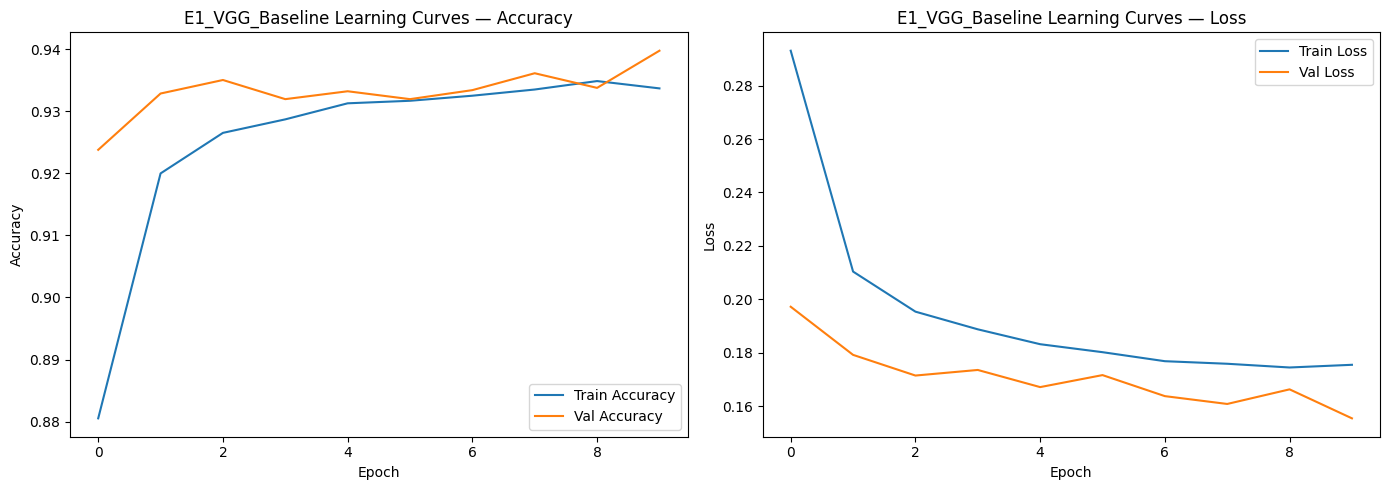

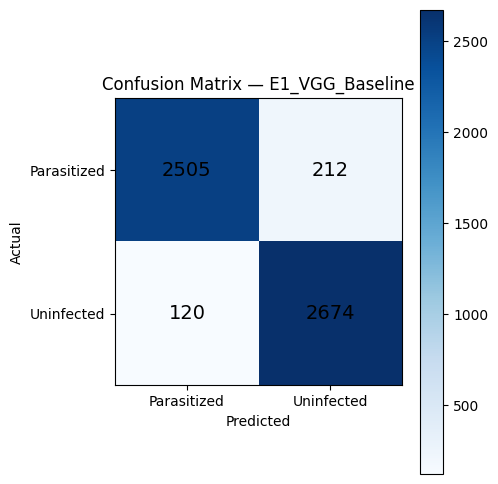

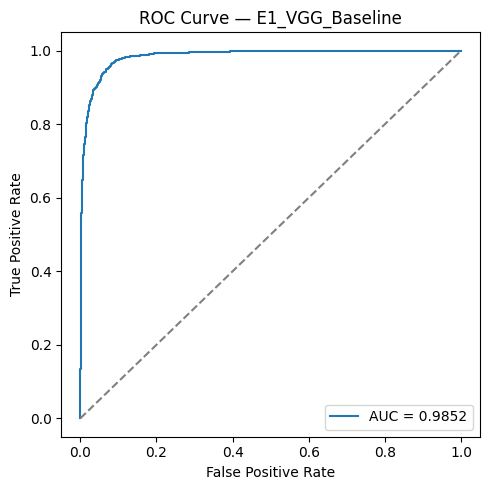

AUC: 0.9852


np.float64(0.9851730231114627)

In [19]:
plot_learning_curves(hist_vgg1, title="E1_VGG_Baseline Learning Curves")
y_true, y_pred, y_scores = all_vgg_preds["E1_VGG_Baseline"]
plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix — E1_VGG_Baseline")
plot_roc_curve(y_true, y_scores, title="ROC Curve — E1_VGG_Baseline")

### E2_VGG_Lower_LR Visualizations

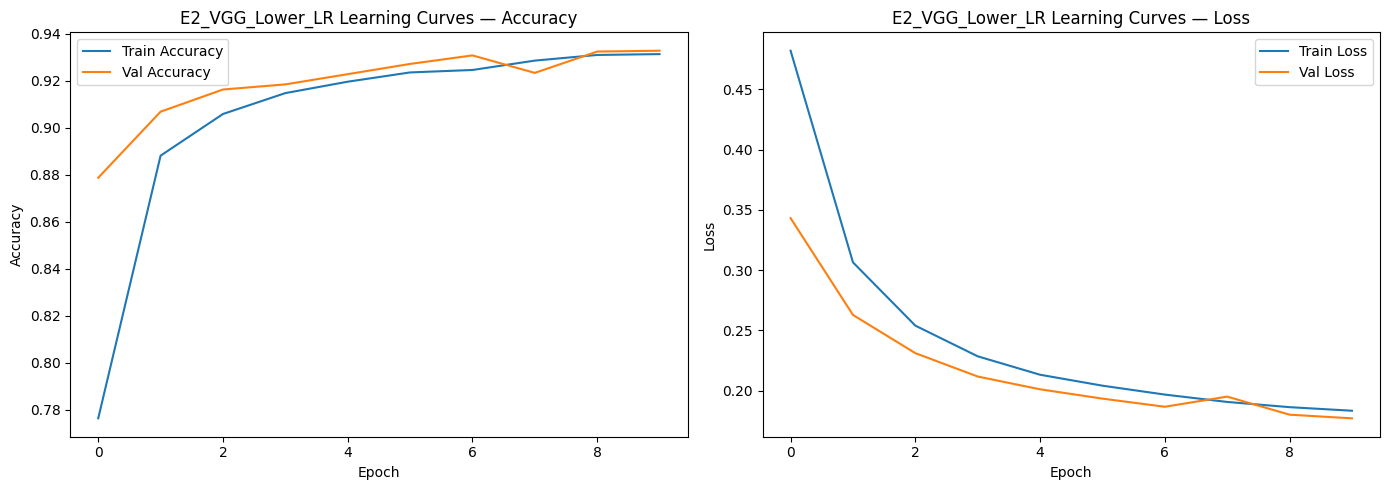

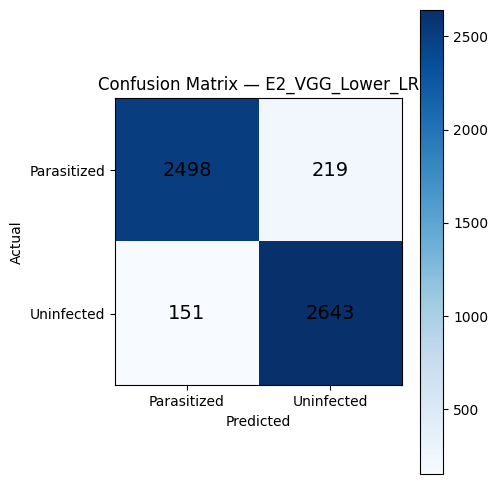

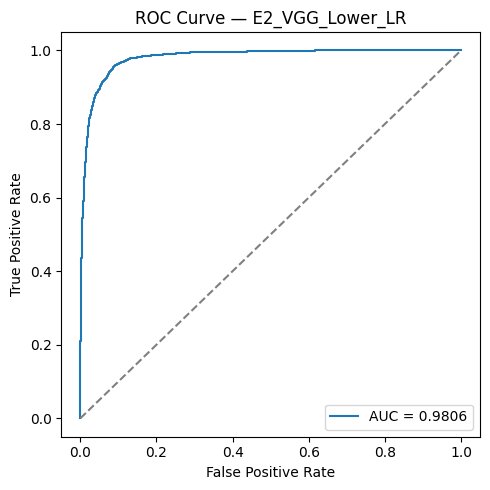

AUC: 0.9806


np.float64(0.9806183343085728)

In [20]:
plot_learning_curves(hist_vgg2, title="E2_VGG_Lower_LR Learning Curves")
y_true, y_pred, y_scores = all_vgg_preds["E2_VGG_Lower_LR"]
plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix — E2_VGG_Lower_LR")
plot_roc_curve(y_true, y_scores, title="ROC Curve — E2_VGG_Lower_LR")

### E3_VGG_SGD_Opt Visualizations

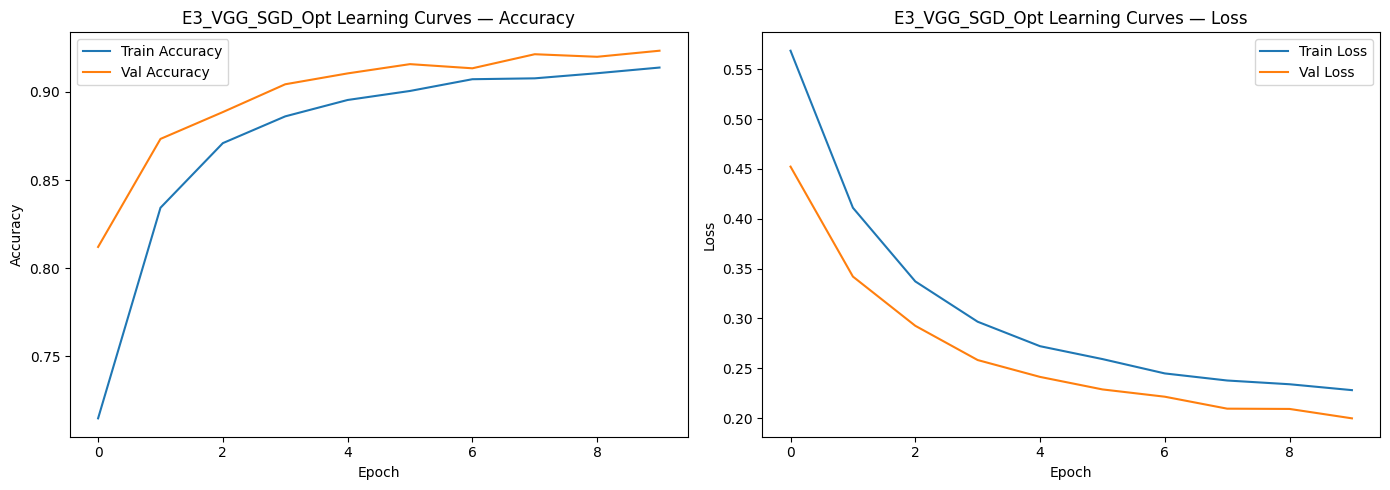

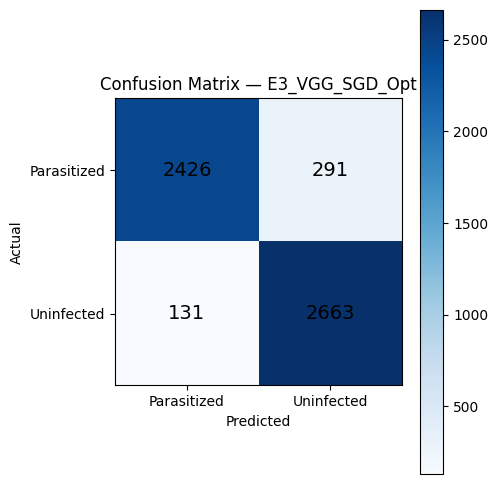

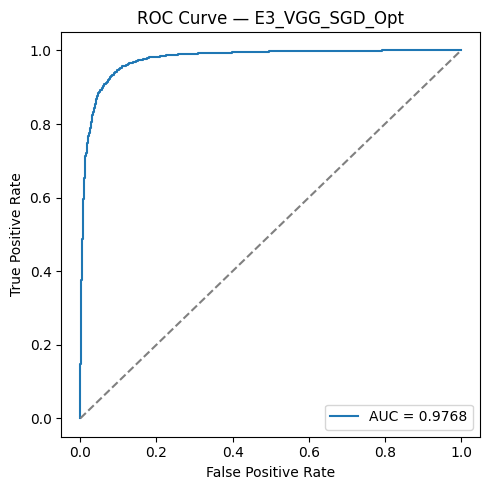

AUC: 0.9768


np.float64(0.9768189840525295)

In [21]:
plot_learning_curves(hist_vgg3, title="E3_VGG_SGD_Opt Learning Curves")
y_true, y_pred, y_scores = all_vgg_preds["E3_VGG_SGD_Opt"]
plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix — E3_VGG_SGD_Opt")
plot_roc_curve(y_true, y_scores, title="ROC Curve — E3_VGG_SGD_Opt")

### E4_VGG_Dense64 Visualizations

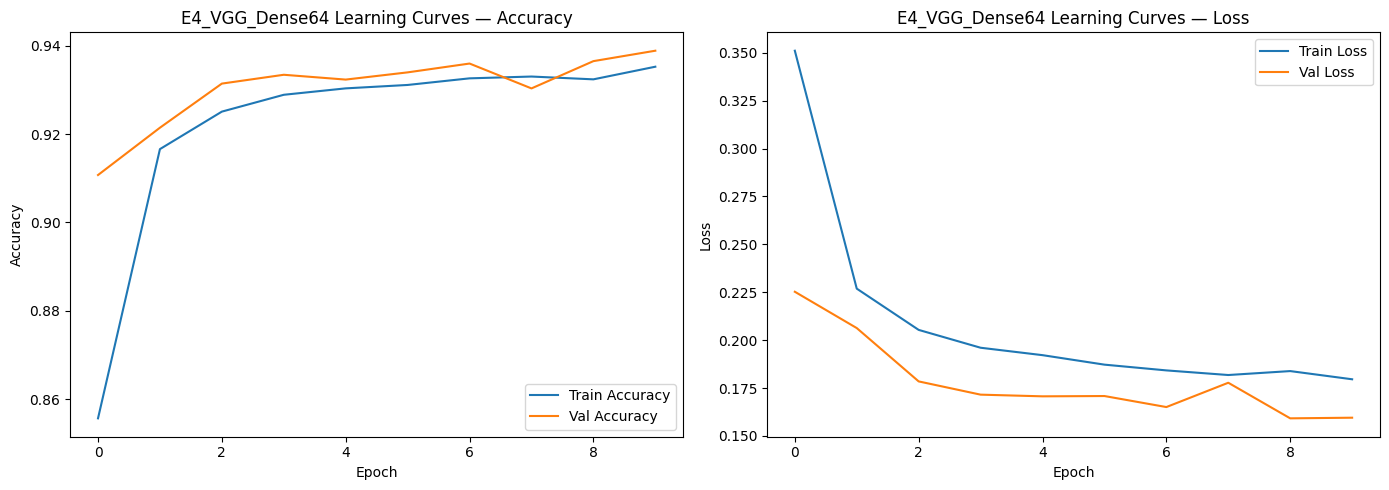

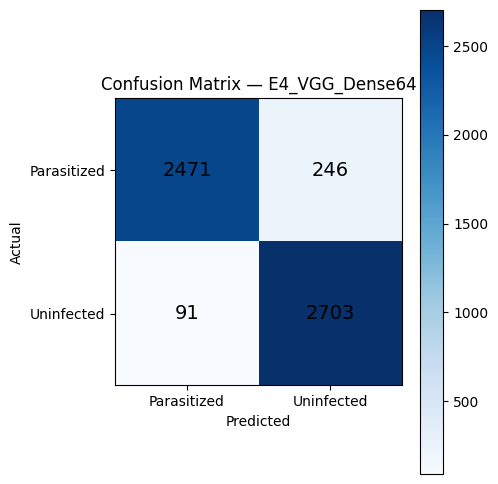

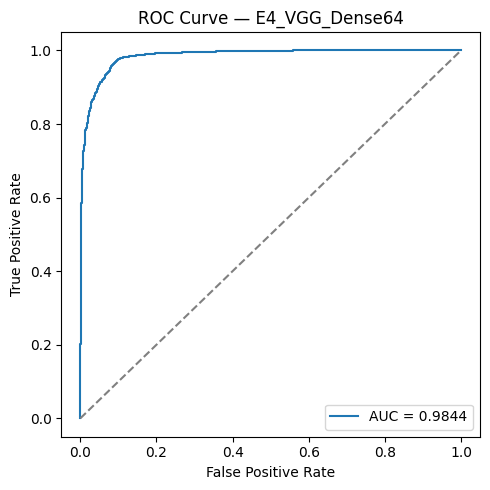

AUC: 0.9844


np.float64(0.9843785608205605)

In [22]:
plot_learning_curves(hist_vgg4, title="E4_VGG_Dense64 Learning Curves")
y_true, y_pred, y_scores = all_vgg_preds["E4_VGG_Dense64"]
plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix — E4_VGG_Dense64")
plot_roc_curve(y_true, y_scores, title="ROC Curve — E4_VGG_Dense64")

### E5_VGG_Dropout0.7 Visualizations

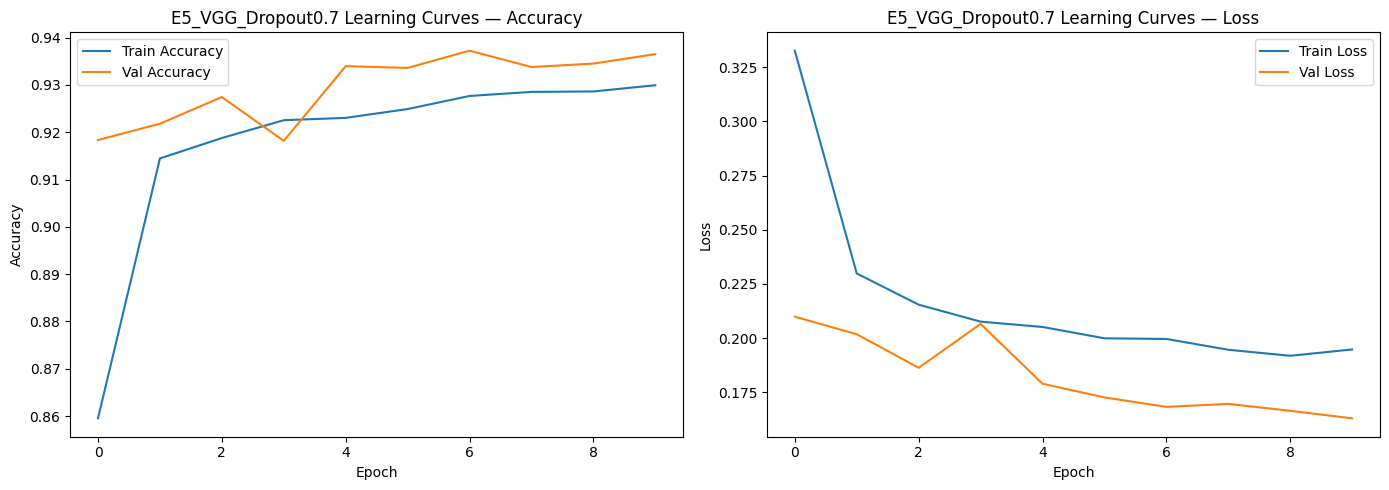

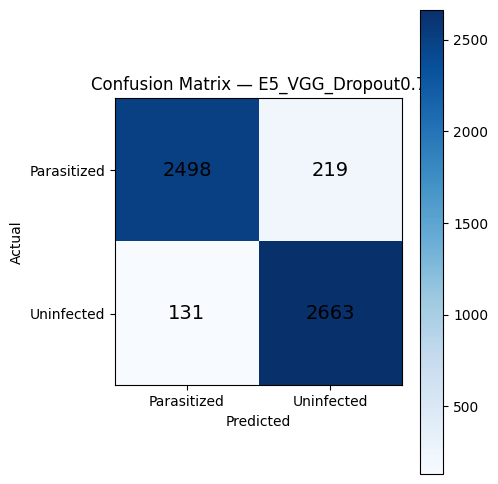

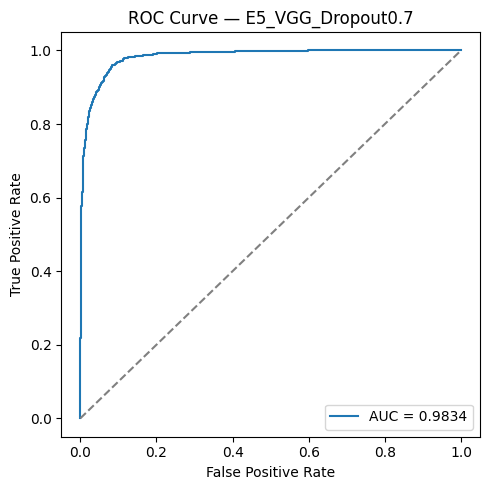

AUC: 0.9834


np.float64(0.9833840009969309)

In [23]:
plot_learning_curves(hist_vgg5, title="E5_VGG_Dropout0.7 Learning Curves")
y_true, y_pred, y_scores = all_vgg_preds["E5_VGG_Dropout0.7"]
plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix — E5_VGG_Dropout0.7")
plot_roc_curve(y_true, y_scores, title="ROC Curve — E5_VGG_Dropout0.7")

### E6_VGG_Dense512 Visualizations

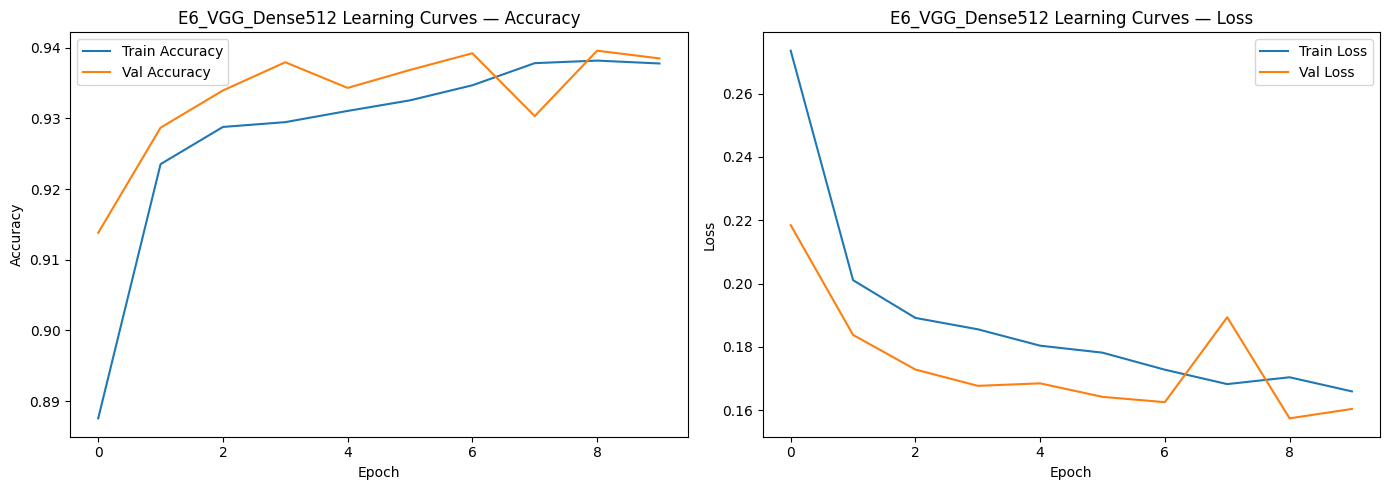

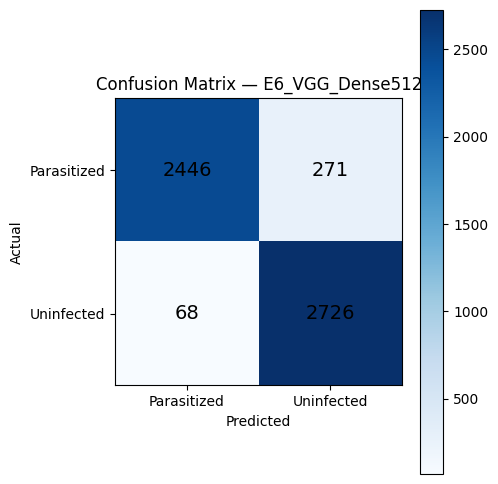

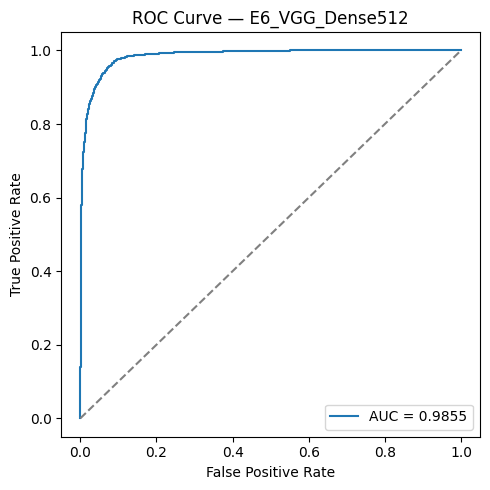

AUC: 0.9855


np.float64(0.9854819294407886)

In [24]:
plot_learning_curves(hist_vgg6, title="E6_VGG_Dense512 Learning Curves")
y_true, y_pred, y_scores = all_vgg_preds["E6_VGG_Dense512"]
plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix — E6_VGG_Dense512")
plot_roc_curve(y_true, y_scores, title="ROC Curve — E6_VGG_Dense512")

## 8. Visualizations (Best Configuration: Experiment 7)

Generating evaluation charts for Experiment 7 Fine-Tuning Optimization...


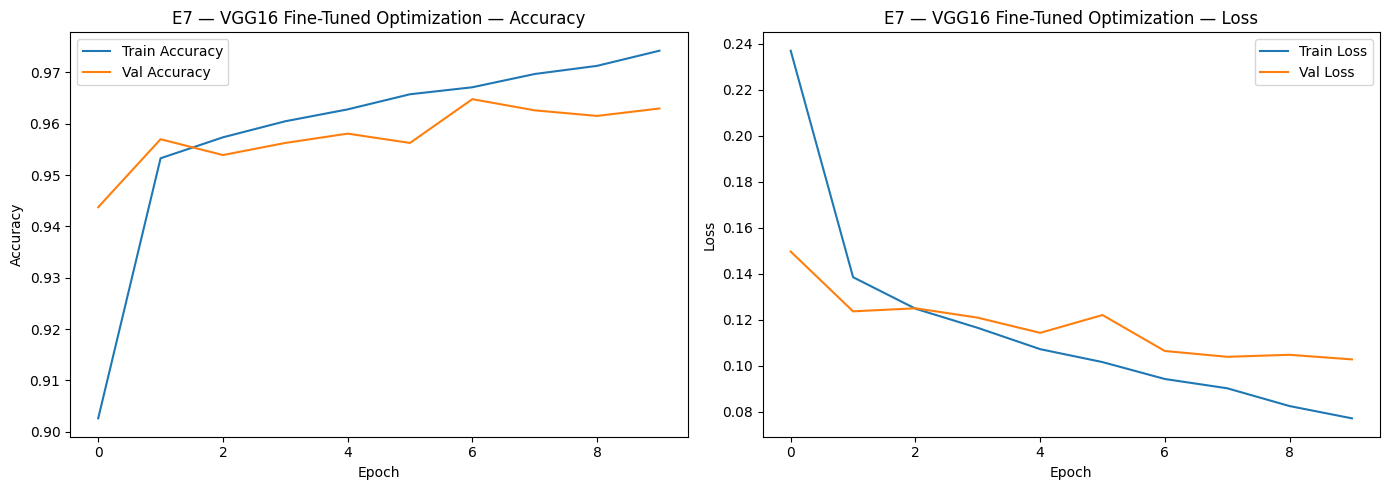

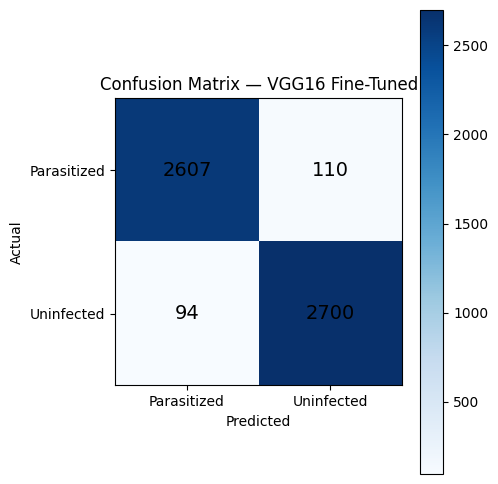

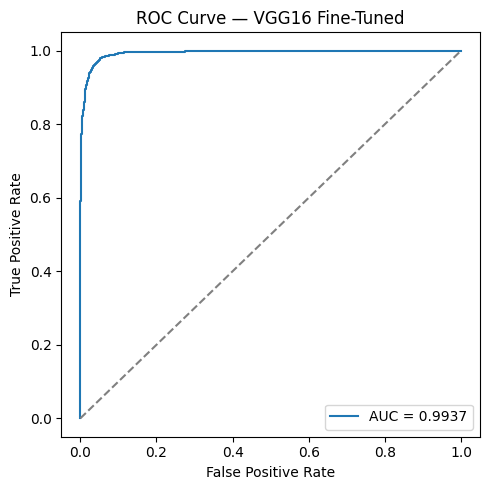

AUC: 0.9937

[Status] Execution complete!!!!


In [16]:
print("Generating evaluation charts for Experiment 7 Fine-Tuning Optimization...")

plot_learning_curves(hist_vgg7, title="E7 — VGG16 Fine-Tuned Optimization")

y_true_ft, y_pred_ft, y_scores_ft = all_vgg_preds["E7_VGG_FineTune"]

plot_confusion_matrix(y_true_ft, y_pred_ft, title="Confusion Matrix — VGG16 Fine-Tuned")
plot_roc_curve(y_true_ft, y_scores_ft, title="ROC Curve — VGG16 Fine-Tuned")

print("\n[Status] Execution complete!!!!")